<a href="https://colab.research.google.com/github/rashmidhanwar-spec/Genomic-Analysis-of-Methanococcales-Using-Tetramer-Frequency-and-Random-Forest-Classifiers/blob/main/Biochar_vs_CFU_mL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving TVC_1.xlsx to TVC_1.xlsx


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
files = [
    "TVC_1.xlsx - Bacillus safensis.csv",
    "TVC_1.xlsx - Pseudomonas korensis.csv"
]

In [4]:
def parse_cfu(val):
  if isinstance(val, str):
    val = val.replace('x10^', 'e')
    try:
      return float(val)
    except ValueError:
      return np.nan
  return val

In [8]:
input_file = 'TVC_1.xlsx'

# 2. Function to convert scientific notation strings (e.g., '1.9x10^5') to numbers
def parse_cfu(val):
    if isinstance(val, str):
        # Standardize format to 'e' notation (e.g., 1.9e5)
        val = val.lower().replace('x10^', 'e').replace('X10^', 'e')
        try:
            return float(val)
        except ValueError:
            return np.nan
    return val

Processing: Bacillus safensis


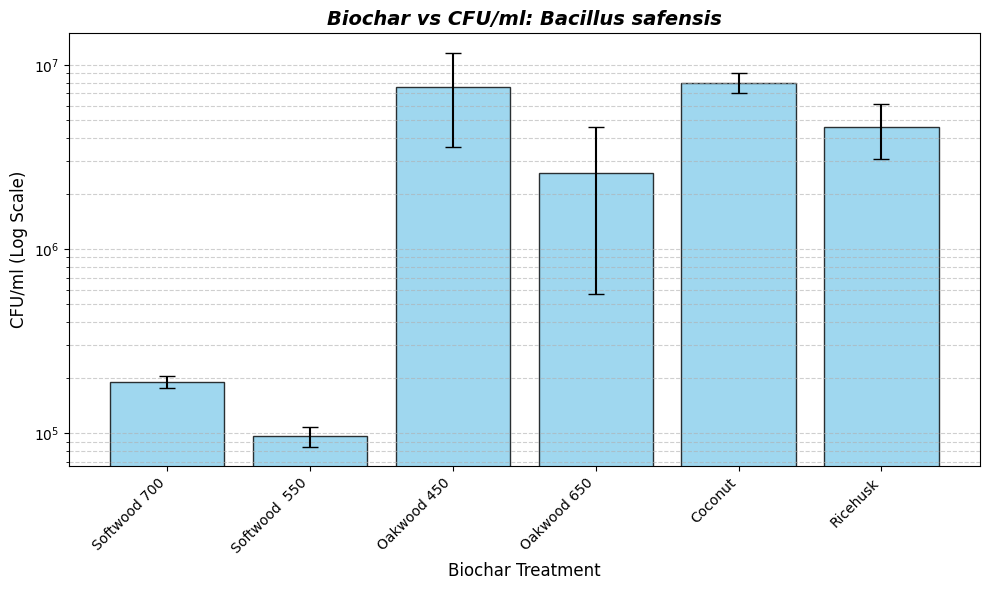

Processing: Pseudomonas korensis


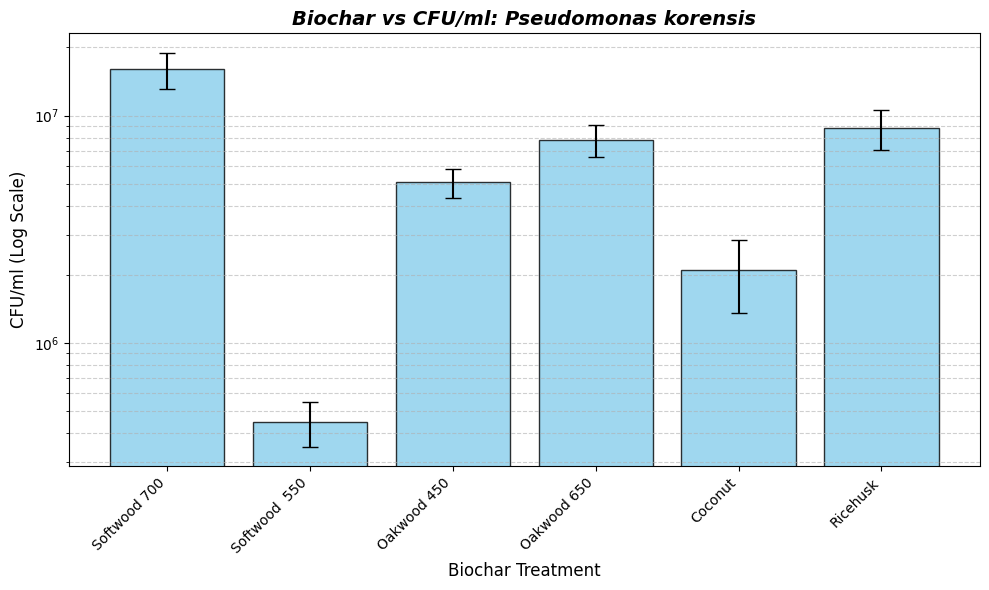

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET YOUR FILENAME ---
# Ensure this file is in the same folder as your script
excel_file = 'TVC_1.xlsx'

def parse_cfu(val):
    """Converts scientific notation strings like '1.9x10^5' into numbers."""
    if isinstance(val, str):
        # Handle different variations of scientific notation strings
        val = val.lower().replace('x10^', 'e').replace(' ', '')
        try:
            return float(val)
        except ValueError:
            return np.nan
    return val

try:
    # --- 2. LOAD DATA ---
    # Note: You may need to run 'pip install openpyxl' to read .xlsx files
    excel_data = pd.read_excel(excel_file, sheet_name=None)

    for sheet_name, df in excel_data.items():
        print(f"Processing: {sheet_name}")

        # --- 3. DATA CLEANING & CALCULATION ---
        # Convert scientific notation strings to numbers
        df['CFU_val'] = df['CFU/ml'].apply(parse_cfu)

        # Calculate standard deviation of the triplicates (T1, T2, T3)
        # This measures the variability of your experiment
        df['std_counts'] = df[['T1', 'T2', 'T3']].std(axis=1)

        # Scale the error bars:
        # Error = Standard Deviation * (Final CFU Value / Average Raw Count)
        # This keeps the error bar size proportional to the CFU/ml value
        df['error_cfu'] = df['std_counts'] * (df['CFU_val'] / df['Average'])

        # --- 4. PLOTTING ---
        plt.figure(figsize=(10, 6))

        # Plot bars with error bars
        plt.bar(df['Biochar'], df['CFU_val'], yerr=df['error_cfu'],
                capsize=6, color='skyblue', edgecolor='black', alpha=0.8)

        # Use a Logarithmic Scale for the Y-axis (Standard for microbial data)
        plt.yscale('log')
        plt.ylabel('CFU/ml (Log Scale)', fontsize=12)
        plt.xlabel('Biochar Treatment', fontsize=12)
        plt.title(f'Biochar vs CFU/ml: {sheet_name}', fontsize=14, fontweight='bold', fontstyle='italic')

        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.6, which='both')
        plt.tight_layout()

        # Save each sheet's graph as an image
        filename = f"plot_{sheet_name.replace(' ', '_')}.png"
        plt.savefig(filename, dpi=300)
        plt.show()

except FileNotFoundError:
    print(f"Error: The file '{excel_file}' was not found in this folder.")
except Exception as e:
    print(f"An error occurred: {e}")